<div style="background: linear-gradient(135deg, #1e3a8a 0%, #3b82f6 100%); padding: 30px; border-radius: 15px; text-align: center; color: white; box-shadow: 0 10px 20px rgba(0,0,0,0.2); margin-bottom: 20px;">
    <h1 style="margin: 0; font-size: 2.5em; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 800; letter-spacing: 2px; text-transform: uppercase;">
        Disaster Tweets Analysis
    </h1>
    <hr style="border: 0; height: 1px; background-image: linear-gradient(to right, rgba(255, 255, 255, 0), rgba(255, 255, 255, 0.75), rgba(255, 255, 255, 0)); margin: 15px 0;">
    <h2 style="margin: 0; font-size: 1.5em; opacity: 0.9; font-weight: 400; font-style: italic;">
        Réseaux de neurones Bi-LSTM
    </h2>
</div>

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Importation
</h3>


In [1]:
import builtins
import pandas as pd
import re
# Suivi des expriences (MLflow & DagsHub)
import dagshub
import mlflow

# Scikit-Learn : Sparation des donnes et mtriques d'valuation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score
)

# TensorFlow / Keras : Cration et entranement du modle Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    DagsHub & MLflow Init
</h3>


In [2]:
# Initialisation de la connexion DagsHub avec les identifiants de votre dépôt et activation du mode MLflow
# PATCH WINDOWS : Force l'utilisation de l'encodage UTF-8 lors de l'écriture des fichiers.

_original_open = builtins.open
def _utf8_open(*args, **kwargs):
    mode = kwargs.get('mode', args[1] if len(args) > 1 else 'r')
    if 'b' not in mode and 'encoding' not in kwargs:
        kwargs['encoding'] = 'utf-8'
    return _original_open(*args, **kwargs)
builtins.open = _utf8_open

dagshub.init(repo_owner='Oscar-AS', repo_name='disaster-tweets-project', mlflow=True)

# Définition du nom du dossier (expérience) dans MLflow où toutes nos métriques seront classées
mlflow.set_experiment("Disaster_Tweets")

# Affichage d'un message console pour confirmer que le tracking est bien connecté
print("MLflow activé avec succès sur DagsHub !")


Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

MLflow activé avec succès sur DagsHub !


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Importation Données
</h3>


In [3]:
# Chargement des données
df = pd.read_csv("../Base/tweets.csv")

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Nettoyage
</h3>


In [4]:
def cleaning_simple(data):
    text = str(data)  # convertir en texte pour éviter les erreurs avec les valeurs manquantes

    text = re.sub(r'https?://\S+|www\.\S+|http?://\S+', ' ', text)  # supprimer les URLs

    text = re.sub(r'<.*?>', ' ', text)  # supprimer les balises HTML

    text = re.sub("["
                  u"\U0001F600-\U0001F64F"
                  u"\U0001F300-\U0001F5FF"
                  u"\U0001F680-\U0001F6FF"
                  u"\U0001F1E0-\U0001F1FF"
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", ' ', text)  # supprimer les émojis et symboles

    text = re.sub(r'@\S+', ' ', text)  # supprimer les mentions @user

    text = re.sub(r'#', '', text)  # supprimer le symbole # mais garder le mot

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # garder uniquement les lettres et les espaces

    text = text.lower()  # convertir en minuscules

    text = re.sub(r'\s+', ' ', text).strip()  # supprimer les espaces multiples

    return text

In [5]:
df["text"] = df["text"].apply(cleaning_simple)

In [6]:
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,communal violence in bhainsa telangana stones ...,1
1,1,ablaze,NaN,telangana section has been imposed in bhainsa ...,1
2,2,ablaze,New York City,arsonist sets cars ablaze at dealership,1
3,3,ablaze,"Morgantown, WV",arsonist sets cars ablaze at dealership,1
4,4,ablaze,NaN,lord jesus your love brings freedom and pardon...,0


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Séparation des données
</h3>


In [7]:

# Séparation Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Affiche dans la console le nombre de tweets utilisés pour l'entraînement
print(f"Taille de l'entraînement : {len(X_train)}")
# Affiche dans la console le nombre de tweets gardés pour le test
print(f"Taille du test : {len(X_test)}")


Taille de l'entraînement : 9096
Taille du test : 2274


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Implémentation des modèles (Réseaux de Neurones avec TensorFlow/Keras)
</h3>


In [8]:

# Définition de la taille maximale du vocabulaire autorisé (les 15000 mots les plus fréquents)
MAX_VOCAB_SIZE = 15000
# Définition de la taille maximale d'une phrase (tronquée si plus longue, remplie par des 0 si plus courte)
MAX_SEQUENCE_LENGTH = 128

# Instanciation de la couche de Vectorisation
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE, # Limite du vocabulaire
    output_mode='int',         # Chaque mot sera remplacé par un nombre entier
    output_sequence_length=MAX_SEQUENCE_LENGTH # Fixe la longueur de toutes les séquences à 128
)

# Apprentissage du vocabulaire : on lit le texte d'entraînement pour créer le dictionnaire mot -> entier
vectorizer.adapt(X_train.to_numpy())

# Fonction utilitaire pour préparer les données afin que TensorFlow s'entraîne plus vite
def prepare_tf_dataset(X, y, batch_size=32):
    # Création d'un dataset TensorFlow à partir de nos listes Python (X et y)
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    # Groupement des données en paquets (batches) de 32, et mise en mémoire cache dynamique (AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Retourne le dataset optimisé
    return dataset

# Création du Dataset d'entraînement accéléré
train_ds = prepare_tf_dataset(X_train, y_train)
# Création du Dataset de test accéléré
test_ds = prepare_tf_dataset(X_test, y_test)

# Importation du module MLflow dédié à TensorFlow
import mlflow.tensorflow
# Activation du suivi automatique (enregistrera la loss, les paramètres et les modèles à chaque epoch sans coder manuellement)
mlflow.tensorflow.autolog(log_models=True)


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Modèle BiLSTM + GRU avec Poids de Classe
</h3>

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Description du modèle
</h3>
C'est une version sous stéroïdes du LSTM, combinant plusieurs architectures récurrentes.

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Explication du fonctionnement
</h3>
<ol>
<li>BiDirectional : Au lieu de lire la phrase uniquement de gauche à droite, la couche Biopt la lit *aussi* de droite à gauche en même temps. Cela permet de comprendre qu'un mot a été influencé par la fin de la phrase.</li>
<li>Couche GRU : Un parent plus moderne et plus léger du opt, ajouté ici pour extraire une dernière série d'informations.</li>
<li>Class Weights : Nous modifions l'équation d'entraînement pour que le modèle soit puni sévèrement s'il rate un tweet de "Désastre" (classe 1).</li>
</ol>



In [ ]:
# Calcul mathématique pour compenser le déséquilibre des classes
# Récupération du nombre total d'exemples d'entraînement
total = len(y_train)
# Comptage du nombre d'exemples positifs (les 1, donc les vrais désastres)
pos = sum(y_train)
# Comptage du nombre d'exemples négatifs (les 0)
neg = total - pos

# Poids pour la classe 0 : un petit nombre (car la classe est majoritaire)
weight_for_0 = (1 / neg) * (total / 2.0)
# Poids pour la classe 1 : un grand nombre (car la classe est minoritaire)
weight_for_1 = (1 / pos) * (total / 2.0)
# Dictionnaire regroupant ces poids pour TensorFlow
class_weights = {0: weight_for_0, 1: weight_for_1}

# Lancement du Run MLflow pour le modèle optimisé
with mlflow.start_run(run_name="Biopt_Optimized"):
    # Définition de la métrique F2-Score pour Keras
    def f2_score(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        return (1 + 4) * (precision * recall) / (4 * precision + recall + tf.keras.backend.epsilon())

    # Architecture avancée du réseau
    model_opt = models.Sequential([
        # Vectorisation
        vectorizer,
        # Embedding plus puissant (128 dimensions au lieu de 64). mask_zero=True ignore le padding vide.
        layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, mask_zero=True),
        # La couche Bidirectional enveloppe le opt. 'return_sequences=True' permet d'enchaîner avec le GRU
        layers.Bidirectional(layers.opt(64, return_sequences=True)),
        # Dropout de 30% pour forcer le modèle à généraliser
        layers.Dropout(0.3),
        # Couche GRU, qui est un RNN plus rapide
        layers.GRU(32),
        # Une couche Dense classique pour extraire les conclusions
        layers.Dense(32, activation='relu'),
        # Un dernier Dropout avant la sortie
        layers.Dropout(0.3),
        # Sortie binaire
        layers.Dense(1, activation='sigmoid')
    ])

    # Utilisation d'un "Learning Rate" (taux d'apprentissage) personnalisé, plus faible que celui par défaut
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    # Compilation
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_biopt.keras',
        monitor='val_f2_score',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    model_opt.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', f2_score])
    # Entraînement sur 5 epochs, EN INCLUANT l'argument 'class_weight' défini plus haut
    model_opt.fit(train_ds, validation_data=test_ds, epochs=5, class_weight=class_weights, callbacks=[checkpoint_cb])

    # Recharger le meilleur modèle
    model_opt = models.load_model('best_model_biopt.keras', custom_objects={'f2_score': f2_score})

    # Transformation des probabilités en entiers 0/1
    y_pred_opt = (model_opt.predict(test_ds) > 0.5).astype(int)

    # Affichage
    print("\n--- Rapport Biopt Optimisé ---")
    print(classification_report(y_test, y_pred_opt))

    # Suivi explicite des métriques de test dans MLflow
    mlflow.log_metric("eval_f1_macro", f1_score(y_test, y_pred_opt, average='macro'))
    mlflow.log_metric("eval_f2_score", fbeta_score(y_test, y_pred_opt, beta=2, average='macro'))

    precision_cls = precision_score(y_test, y_pred_opt, average=None)
    recall_cls = recall_score(y_test, y_pred_opt, average=None)
    mlflow.log_metric("eval_precision_class_0", precision_cls[0])
    mlflow.log_metric("eval_precision_class_1", precision_cls[1])
    mlflow.log_metric("eval_recall_class_0", recall_cls[0])
    mlflow.log_metric("eval_recall_class_1", recall_cls[1])
    mlflow.log_metric("eval_accuracy", accuracy_score(y_test, y_pred_opt))

    # Enregistrement explicite du modèle pour la mise en production
    try:
        mlflow.tensorflow.log_model(model_opt, "model")
    except Exception as e:
        print("Erreur lors de la sauvegarde du modèle Keras :", e)


2026/05/08 12:27:21 WARNING mlflow.tensorflow: Encountered unexpected error while inferring batch size from training dataset: Sequential model 'sequential' has no defined input shape yet.


Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6915 - f2_score: 0.2033 - loss: 0.6903
Epoch 1: val_f2_score improved from None to 0.20237, saving model to best_model_bilstm.keras

Epoch 1: finished saving model to best_model_bilstm.keras


285/285 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.7617 - f2_score: 0.1656 - loss: 0.6800 - val_accuracy: 0.8531 - val_f2_score: 0.2024 - val_loss: 0.4851
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7827 - f2_score: 0.2772 - loss: 0.5082
Epoch 2: val_f2_score did not improve from 0.20237


285/285 ━━━━━━━━━━━━━━━━━━━━ 912s 3s/step - accuracy: 0.8171 - f2_score: 0.2631 - loss: 0.4425 - val_accuracy: 0.8760 - val_f2_score: 0.1951 - val_loss: 0.3372
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9035 - f2_score: 0.2256 - loss: 0.2793
Epoch 3: val_f2_score did not improve from 0.20237


285/285 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.9126 - f2_score: 0.2218 - loss: 0.2532 - val_accuracy: 0.8760 - val_f2_score: 0.1845 - val_loss: 0.3372
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9546 - f2_score: 0.2051 - loss: 0.1544
Epoch 4: val_f2_score did not improve from 0.20237
285/285 ━━━━━━━━━━━━━━━━━━━━ 206s 715ms/step - accuracy: 0.9594 - f2_score: 0.2041 - loss: 0.1380 - val_accuracy: 0.8588 - val_f2_score: 0.1968 - val_loss: 0.4263
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9728 - f2_score: 0.1976 - loss: 0.0962
Epoch 5: val_f2_score did not improve from 0.20237
285/285 ━━━━━━━━━━━━━━━━━━━━ 99s 342ms/step - accuracy: 0.9763 - f2_score: 0.1976 - loss: 0.0871 - val_accuracy: 0.8654 - val_f2_score: 0.1833 - val_loss: 0.4754


2026/05/08 13:00:11 WARNING mlflow.tensorflow: Failed to infer model signature: Invalid dtype: object
2026/05/08 13:00:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 13:00:18 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/08 13:02:28 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpss4zgi27\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step

--- Rapport BiLSTM Optimisé ---
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1851
           1       0.59      0.66      0.63       423

    accuracy                           0.85      2274
   macro avg       0.76      0.78      0.77      2274
weighted avg       0.86      0.85      0.86      2274



2026/05/08 13:07:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 13:07:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/08 13:09:37 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpqus_z4se\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run BiLSTM_Optimized at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4/runs/5e2188f3d41f4b6bb51cc09bf9407e73
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4


In [10]:
# Tableau récapitulatif des métriques du modèle opt
report_opt = classification_report(y_test, y_pred_opt, output_dict=True, zero_division=0)
f2_class_opt = fbeta_score(y_test, y_pred_opt, beta=2, average=None, zero_division=0)
f2_macro_opt = fbeta_score(y_test, y_pred_opt, beta=2, average="macro", zero_division=0)
f2_weighted_opt = fbeta_score(y_test, y_pred_opt, beta=2, average="weighted", zero_division=0)

metrics_table_opt = (
    pd.DataFrame(report_opt)
    .transpose()
    .rename(index={
        "0": "Non disaster",
        "1": "Disaster",
        "accuracy": "Accuracy",
        "macro avg": "Macro average",
        "weighted avg": "Weighted average",
    })
)

metrics_table_opt["f2-score"] = pd.NA
metrics_table_opt.loc["Non disaster", "f2-score"] = f2_class_opt[0]
metrics_table_opt.loc["Disaster", "f2-score"] = f2_class_opt[1]
metrics_table_opt.loc["Macro average", "f2-score"] = f2_macro_opt
metrics_table_opt.loc["Weighted average", "f2-score"] = f2_weighted_opt

metrics_table_opt = metrics_table_opt[["precision", "recall", "f1-score", "f2-score", "support"]]
metrics_table_opt.round(3)


,precision,recall,f1-score,f2-score,support
Non disaster,0.920,0.897,0.909,0.901835,1851.000
Disaster,0.595,0.660,0.626,0.645534,423.000
Accuracy,0.853,0.853,0.853,<NA>,0.853
Macro average,0.758,0.778,0.767,0.773685,2274.000
Weighted average,0.860,0.853,0.856,0.854159,2274.000


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


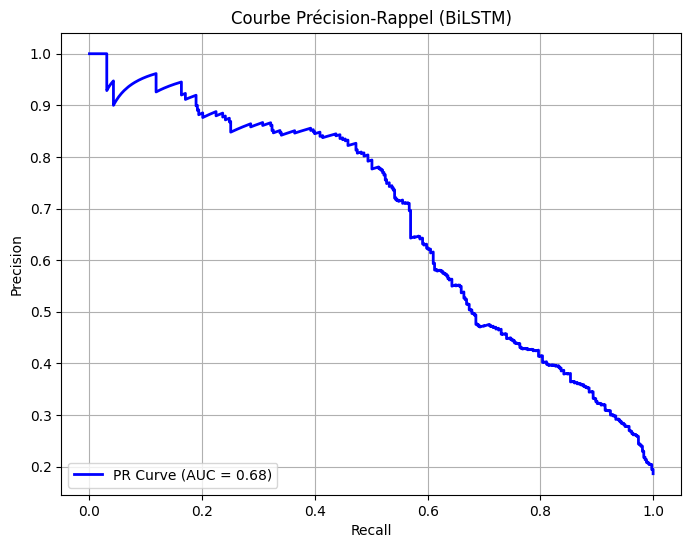

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd

# 1. Calcul des probabilités de prédiction
y_probs = model_opt.predict(test_ds).ravel()

# 2. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel (BiLSTM)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Courbe de Lift
# Trier les probabilités par ordre décroissant
data = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs})
data = data.sort_values(by='y_prob', ascending=False)
data['cumulative_data_fraction'] = np.arange(1, len(data) + 1) / len(data)
data['cumulative_positive_rate'] = data['y_true'].cumsum() / data['y_true'].sum()
data['lift'] = data['cumulative_positive_rate'] / data['cumulative_data_fraction']

plt.figure(figsize=(8, 6))
plt.plot(data['cumulative_data_fraction'], data['lift'], label='Lift Curve', color='orange', lw=2)
plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Random)')
plt.xlabel('Fraction of data')
plt.ylabel('Lift')
plt.title('Courbe de Lift (BiLSTM)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()